In [ ]:
"""
Meshless PDE Integrator — Geometric Basis {1, dx, dt}
------------------------------------------------------
- FD grid used as coordinate scaffold only.
- Geometric weights: no PDE knowledge, just first-order consistency.
- Full debug output to diagnose rejections.
"""

import time
import numpy as np
from scipy.spatial import KDTree
from scipy.interpolate import RegularGridInterpolator

# ── PDE parameters ────────────────────────────────────────────────────────────
alpha = 0.05
c     = 0.5
T     = 0.1

def u_true(x, t):
    return np.sin(np.pi * x) * np.exp(-(alpha * np.pi**2 + c) * t)


# ── FD reference grid ─────────────────────────────────────────────────────────
nx_fd = 100
x_fd  = np.linspace(0.0, 1.0, nx_fd)
dx_fd = x_fd[1] - x_fd[0]

dt_cfl = min(0.9  * dx_fd / c,
             0.45 * dx_fd**2 / alpha)
nt_fd  = max(int(np.ceil(T / dt_cfl)) + 1, 10)
t_fd   = np.linspace(0.0, T, nt_fd)
dt_fd  = t_fd[1] - t_fd[0]


def build_fd_reference():
    u = np.zeros((nx_fd, nt_fd))
    u[:, 0] = u_true(x_fd, 0.0)

    r_diff = alpha * dt_fd / dx_fd**2
    r_adv  = c     * dt_fd / dx_fd

    for it in range(nt_fd - 1):
        un = u[:, it]
        u[1:-1, it+1] = (un[1:-1]
                         - r_adv  * (un[1:-1] - un[:-2])
                         + r_diff * (un[2:] - 2*un[1:-1] + un[:-2]))
        u[0,  it+1] = 0.0
        u[-1, it+1] = 0.0

    interp = RegularGridInterpolator(
        (x_fd, t_fd), u, method='linear',
        bounds_error=False, fill_value=None
    )
    return u, interp


# ── Integrator hyperparameters ────────────────────────────────────────────────
max_points     = 5000

n_neighbours   = 5
cond_max       = 1e6     # relaxed — geometric basis has higher cond naturally
isotropy_max   = 100.0   # relaxed
w_max_factor   = 10.0     # relaxed — geometric weights less constrained
w_min_floor    = -2.0    # relaxed

spawn_nx       = 5
spawn_nt       = 10

box_n0         = 2.0
box_grow       = 1.5
box_nmax       = 15.0

max_candidates = 10_000


# ── KDTree-backed visited set ─────────────────────────────────────────────────
class VisitedSet:
    def __init__(self, rebuild_every=200):
        self._pts           = []
        self._tree          = None
        self._dirty         = 0
        self._rebuild_every = rebuild_every

    def add(self, x, t, u):
        self._pts.append((x, t, u))
        self._dirty += 1
        if self._dirty >= self._rebuild_every:
            self._rebuild()

    def _rebuild(self):
        norm       = np.array([[p[0]/dx_fd, p[1]/dt_fd] for p in self._pts])
        self._tree = KDTree(norm)
        self._dirty = 0

    def _ensure(self):
        if self._tree is None or self._dirty > 0:
            self._rebuild()

    def find_neighbours(self, x_star, t_star):
        """
        Expanding normalised-box search.
        Only returns points strictly in the past (t < t_star).
        Returns list of n_neighbours (x, t, u) tuples, or None.
        """
        self._ensure()
        xn = x_star / dx_fd
        tn = t_star / dt_fd
        bn = box_n0

        while bn <= box_nmax:
            idxs = self._tree.query_ball_point([xn, tn], r=bn, p=np.inf)
            nb = [
                self._pts[i] for i in idxs
                if 0 < (t_star - self._pts[i][1]) <= bn * dt_fd
                and abs(self._pts[i][0] - x_star) <= bn * dx_fd
            ]
            if len(nb) >= n_neighbours:
                nb.sort(key=lambda p: (p[0]-x_star)**2 + (p[1]-t_star)**2)
                return nb[:n_neighbours]
            bn = min(bn * box_grow, box_nmax)

        return None

    def is_too_close(self, x, t, tol=0.4):
        self._ensure()
        idxs = self._tree.query_ball_point([x/dx_fd, t/dt_fd], r=tol, p=np.inf)
        return len(idxs) > 0

    def __len__(self):
        return len(self._pts)


# ── Stencil geometry check ────────────────────────────────────────────────────
def stencil_is_good(dx_i, dt_i, debug=False):
    # Two-sided spatial coverage
    if np.min(dx_i) * np.max(dx_i) > 0:
        if debug: print(f"    [geom] failed two-sided: min={np.min(dx_i):.3f} max={np.max(dx_i):.3f}")
        return False

    # Minimum spatial span
    span = np.max(dx_i) - np.min(dx_i)
    if span < 0.9 * dx_fd:
        if debug: print(f"    [geom] failed span: {span:.4f} < {0.9*dx_fd:.4f}")
        return False

    # Collinearity check via eigenvalue ratio
    h   = max(np.max(np.abs(dx_i)), 1e-12)
    tau = max(np.max(np.abs(dt_i)), 1e-12)
    pts = np.column_stack([dx_i / h, dt_i / tau])
    ev  = np.linalg.eigvalsh(pts.T @ pts)
    ratio = ev[1] / ev[0] if ev[0] > 1e-14 else np.inf
    if ev[0] < 1e-14 or ratio > isotropy_max:
        if debug: print(f"    [geom] failed isotropy: ratio={ratio:.1f} > {isotropy_max}")
        return False

    return True


# ── Weight solver — adaptive geometric basis ──────────────────────────────────
def solve_weights(dx_i, dt_i, debug=False):
    """
    Adaptive basis selection:
      - Near IC (neighbours all at same t): {1, dx, dx²}  — spatial only
      - Away from IC (temporal spread):     {1, dx, dt, dx²} — full basis
    Axes normalised separately so dx and dt don't compete.
    Returns (w, cond) or (None, cond).
    """
    h   = max(np.max(np.abs(dx_i)), 1e-12)
    tau = max(np.max(np.abs(dt_i)), 1e-12)

    temporal_spread = np.std(dt_i)

    if temporal_spread < 0.1 * tau:
        # All neighbours at same time level — dt row would be degenerate
        # Use spatial-only basis: {1, dx, dx²}
        A = np.array([
            np.ones(len(dx_i)),
            dx_i / h,
            dx_i**2 / h**2,
        ])
        basis_name = 'spatial {1, dx, dx²}'
    else:
        # Full spatiotemporal basis: {1, dx, dt, dx²}
        A = np.array([
            np.ones(len(dx_i)),
            dx_i / h,
            dt_i / tau,
            dx_i**2 / h**2,
        ])
        basis_name = 'full {1, dx, dt, dx²}'

    b = np.zeros(len(A))
    b[0] = 1.0

    cond = np.linalg.cond(A)
    if debug: print(f"    [weights] basis={basis_name}  cond={cond:.2e}  temporal_spread={temporal_spread:.2e}")

    if cond > cond_max:
        if debug: print(f"    [weights] REJECTED cond too high")
        return None, cond

    w = np.linalg.lstsq(A, b, rcond=None)[0]

    pou  = abs(np.sum(w) - 1.0)
    wmax = np.max(np.abs(w))
    wmin = np.min(w)

    if debug:
        print(f"    [weights] sum(w)={np.sum(w):.6f}  max|w|={wmax:.3f}  min(w)={wmin:.3f}")

    if pou > 1e-6:
        if debug: print(f"    [weights] REJECTED partition of unity: {pou:.2e}")
        return None, cond
    if wmax > w_max_factor / len(dx_i):
        if debug: print(f"    [weights] REJECTED weight too large: {wmax:.3f} > {w_max_factor/len(dx_i):.3f}")
        return None, cond
    if wmin < w_min_floor:
        if debug: print(f"    [weights] REJECTED weight too negative: {wmin:.3f}")
        return None, cond

    return w, cond


# ── Main integrator ───────────────────────────────────────────────────────────
def run_integrator(seed=None, debug_first_n=5):
    """
    debug_first_n: print detailed diagnostics for the first N candidate attempts.
    """
    t_wall = time.time()
    if seed is not None:
        np.random.seed(seed)

    print("Building FD reference...", flush=True)
    _, fd_interp = build_fd_reference()
    print(f"  dx={dx_fd:.4f}  dt={dt_fd:.5f}", flush=True)

    # IC + BC into visited set
    visited = VisitedSet()
    for ix in range(nx_fd):
        visited.add(x_fd[ix], 0.0, u_true(x_fd[ix], 0.0))
    for it in range(1, nt_fd):
        visited.add(0.0, t_fd[it], 0.0)
        visited.add(1.0, t_fd[it], 0.0)
    print(f"  IC+BC points: {len(visited)}", flush=True)

    # Candidate pool
    cand_keys = set()
    cand_list = []
    def push(ix, it):
        if (ix, it) not in cand_keys:
            cand_keys.add((ix, it))
            cand_list.append((x_fd[ix], t_fd[it]))

    # Seed candidates from IC
    for ix in range(1, nx_fd - 1):
        for dix in range(-spawn_nx, spawn_nx + 1):
            for dit in range(1, spawn_nt + 1):
                nix, nit = ix + dix, dit
                if 1 <= nix <= nx_fd - 2 and nit < nt_fd:
                    push(nix, nit)

    print(f"  Initial candidates: {len(cand_list)}", flush=True)
    print(f"  Stopping at {max_points} computed points", flush=True)
    print(f"  Hyperparams: cond_max={cond_max:.0e}  w_max_factor={w_max_factor}"
          f"  w_min_floor={w_min_floor}  isotropy_max={isotropy_max}\n", flush=True)

    rej        = dict(proximity=0, no_nb=0, geometry=0, cond=0, weights=0, bounds=0)
    point_data = []
    attempt    = 0

    while cand_list and len(point_data) < max_points:

        # Trim oldest candidates if over budget
        if len(cand_list) > max_candidates:
            del cand_list[:len(cand_list) - max_candidates]

        # O(1) swap-and-pop
        idx            = np.random.randint(len(cand_list))
        x_star, t_star = cand_list[idx]
        cand_list[idx] = cand_list[-1]
        cand_list.pop()
        ix_s = int(round(x_star / dx_fd))
        it_s = int(round(t_star / dt_fd))
        cand_keys.discard((ix_s, it_s))

        attempt += 1
        dbg = (attempt <= debug_first_n)

        if dbg:
            print(f"\n── Attempt {attempt}: x={x_star:.4f}  t={t_star:.4f} ──")

        # ── Proximity check ───────────────────────────────────────────────
        if visited.is_too_close(x_star, t_star):
            rej['proximity'] += 1
            if dbg: print("  REJECTED: too close to existing point")
            continue

        # ── Neighbour search ──────────────────────────────────────────────
        nb = visited.find_neighbours(x_star, t_star)
        if nb is None:
            rej['no_nb'] += 1
            if dbg: print("  REJECTED: no neighbours found")
            continue

        nb_pts = np.array(nb)
        dx_i   = nb_pts[:, 0] - x_star
        dt_i   = nb_pts[:, 1] - t_star

        if dbg:
            print(f"  Neighbours found: {len(nb)}")
            for p in nb:
                print(f"    x={p[0]:.4f}  t={p[1]:.4f}  u={p[2]:.4f}")

        # ── Geometry check ────────────────────────────────────────────────
        if not stencil_is_good(dx_i, dt_i, debug=dbg):
            rej['geometry'] += 1
            if dbg: print("  REJECTED: bad stencil geometry")
            continue

        # ── Weight solve ──────────────────────────────────────────────────
        w, cond = solve_weights(dx_i, dt_i, debug=dbg)
        if w is None:
            rej['cond' if cond > cond_max else 'weights'] += 1
            if dbg: print("  REJECTED: weight solve failed")
            continue

        # ── Bounds check ──────────────────────────────────────────────────
        u_hat = float(w @ nb_pts[:, 2])
        if abs(u_hat) > u_bound:
            rej['bounds'] += 1
            if dbg: print(f"  REJECTED: u_hat={u_hat:.4f} out of bounds")
            continue

        # ── Accept ────────────────────────────────────────────────────────
        if dbg:
            print(f"  ACCEPTED: u_hat={u_hat:.6f}  cond={cond:.2e}")

        visited.add(x_star, t_star, u_hat)

        for dix in range(-spawn_nx, spawn_nx + 1):
            for dit in range(1, spawn_nt + 1):
                nix = ix_s + dix
                nit = it_s + dit
                if 1 <= nix <= nx_fd - 2 and nit < nt_fd:
                    push(nix, nit)

        u_ref = float(fd_interp([[x_star, t_star]])[0])
        point_data.append({
            'x':    x_star,
            't':    t_star,
            'u':    u_hat,
            'err':  abs(u_hat - u_ref),
            'cond': cond,
        })

        if len(point_data) % 200 == 0:
            errs  = [p['err'] for p in point_data]
            t_max = max(p['t'] for p in point_data)
            print(f"  {len(point_data):5d} pts | "
                  f"mean={np.mean(errs):.2e} | "
                  f"max={np.max(errs):.2e} | "
                  f"t_max={t_max:.3f} | "
                  f"cands={len(cand_list):5d} | "
                  f"wall={time.time()-t_wall:.1f}s",
                  flush=True)

    # ── Summary ───────────────────────────────────────────────────────────────
    print(f"\n{'─'*56}")
    print(f"  Computed  : {len(point_data)} points")
    print(f"  Total attempts: {attempt}")

    total_rej = sum(rej.values())
    print(f"\n  Rejections ({total_rej} total):")
    for r, n in rej.items():
        pct = 100 * n / attempt if attempt > 0 else 0
        print(f"    {r:12s}: {n:6d}  ({pct:.1f}%)")

    if len(point_data) == 0:
        print("\n  !! No points computed — check rejection breakdown above.")
        return visited, point_data, fd_interp

    errs = np.array([p['err'] for p in point_data])
    print(f"\n  Mean err  : {errs.mean():.3e}")
    print(f"  Max  err  : {errs.max():.3e}")
    print(f"  Wall time : {time.time()-t_wall:.1f}s")

    return visited, point_data, fd_interp


if __name__ == '__main__':
    visited, point_data, fd_interp = run_integrator(seed=42, debug_first_n=5)

Building FD reference...


  dx=0.0101  dt=0.00092
  IC+BC points: 318
  Initial candidates: 980
  Stopping at 5000 computed points
  Hyperparams: cond_max=1e+06  w_max_factor=10.0  w_min_floor=-2.0  isotropy_max=100.0


── Attempt 1: x=0.1111  t=0.0028 ──
  Neighbours found: 5
    x=0.1111  t=0.0000  u=0.3420
    x=0.1010  t=0.0000  u=0.3120
    x=0.1212  t=0.0000  u=0.3717
    x=0.0909  t=0.0000  u=0.2817
    x=0.1313  t=0.0000  u=0.4009
    [weights] basis=spatial {1, dx, dx²}  cond=3.08e+00  temporal_spread=0.00e+00
    [weights] sum(w)=1.000000  max|w|=0.486  min(w)=-0.086
  ACCEPTED: u_hat=0.342020  cond=3.08e+00

── Attempt 2: x=0.4444  t=0.0055 ──
  Neighbours found: 5
    x=0.4444  t=0.0000  u=0.9848
    x=0.4343  t=0.0000  u=0.9788
    x=0.4545  t=0.0000  u=0.9898
    x=0.4242  t=0.0000  u=0.9718
    x=0.4646  t=0.0000  u=0.9938
    [weights] basis=spatial {1, dx, dx²}  cond=3.08e+00  temporal_spread=0.00e+00
    [weights] sum(w)=1.000000  max|w|=0.486  min(w)=-0.086
  ACCEPTED: u_hat=0.984808  cond=3.

KeyboardInterrupt: 

: 

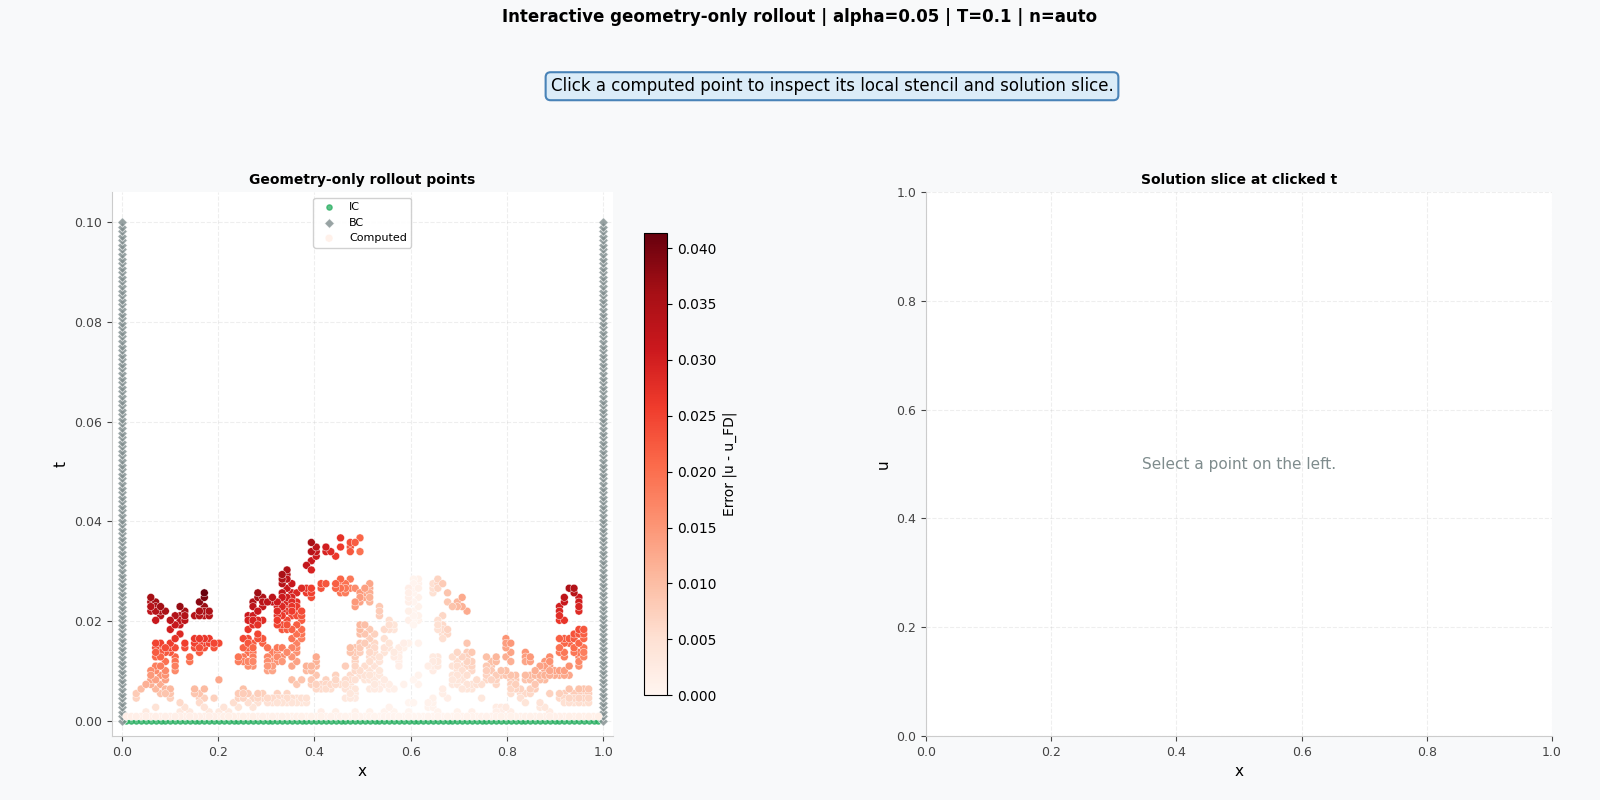

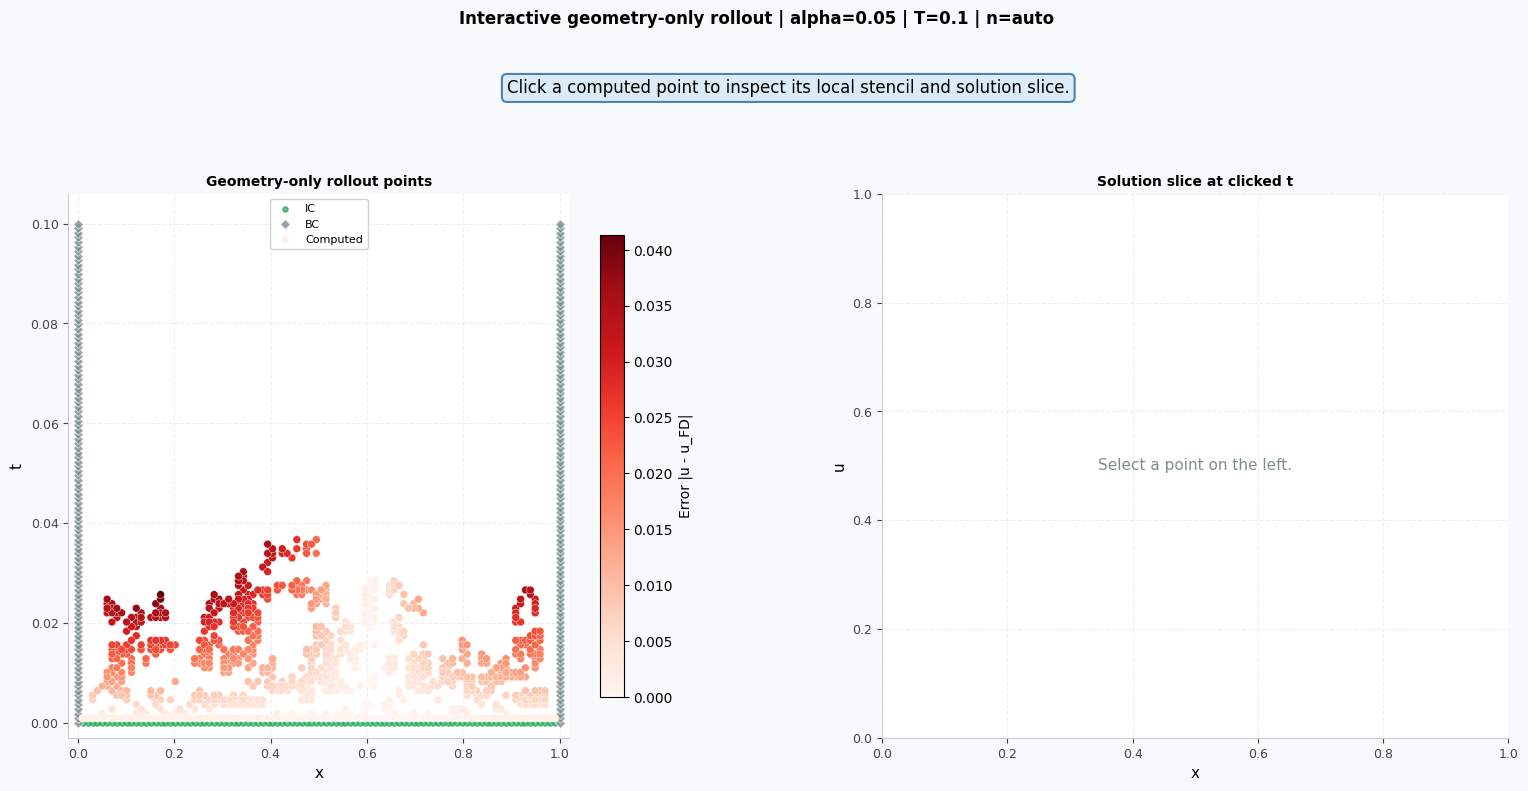

In [ ]:
%matplotlib widget
from Plots.interactive_plot_geometry import interactive_plot
from Plots.error_analysis import error_analysis

# Extract IC and BC coordinates from visited._pts           
ic_x = np.array([p[0] for p in visited._pts if p[1] == 0.0 and 0 < p[0] < 1.0])
ic_t = np.array([p[1] for p in visited._pts if p[1] == 0.0 and 0 < p[0] < 1.0])

bc_x = np.array([p[0] for p in visited._pts if p[0] in [0.0, 1.0]])
bc_t = np.array([p[1] for p in visited._pts if p[0] in [0.0, 1.0]])

interactive_plot(
    point_data,
    visited._pts,   # pass the raw list so the plot code sees (x, t, u) tuples
    u_true,
    fd_interp,
    T,
    dt_fd,          # was dt_sc
    ic_x,
    ic_t,
    bc_x,
    bc_t
)